In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data
df_att_25 = pd.read_csv('attendance data season 2024-25.csv')

### trying to find all star break

### 5 games before (V - H):
# Pittsburgh Penguins - Philadelphia Flyers
# Dallas Stars - San Jose Sharks
# Chicago Blackhawks - St. Louis Blues
# Toronto Maple Leafs - Vancouver Canucks
# Tampa Bay Lightning - Montreal Canadiens
# Utah Hockey Club - Washington Capitals <-- not included in dataframe (but technically last game before break)

### 5 games after (V - H):
# Anaheim Ducks - Boston Bruins
# New York Rangers - Buffalo Sabres
# Chicago Blackhawks - Columbus Blue Jackets
# Minnesota Wild - Detroit Red Wings
# Seattle Kraken - Florida Panthers

display(df_att_25.head())

# Helper to find index of a specific matchup
def find_game_index(visitor, home):
    return df_att_25[(df_att_25['H'] == home) & (df_att_25['V'] == visitor)].index[0]

# 5 games before the break
before_indices = [
    find_game_index('Pittsburgh Penguins', 'Philadelphia Flyers'),
    find_game_index('Dallas Stars', 'San Jose Sharks'),
    find_game_index('Chicago Blackhawks', 'St. Louis Blues'),
    find_game_index('Toronto Maple Leafs', 'Vancouver Canucks'),
    find_game_index('Tampa Bay Lightning', 'Montreal Canadiens'),
]

# 5 games after the break
after_indices = [
    find_game_index('Anaheim Ducks', 'Boston Bruins'),
    find_game_index('New York Rangers', 'Buffalo Sabres'),
    find_game_index('Chicago Blackhawks', 'Columbus Blue Jackets'),
    find_game_index('Minnesota Wild', 'Detroit Red Wings'),
    find_game_index('Seattle Kraken', 'Florida Panthers')
]

# Estimate the break index as halfway between the last "before" and first "after"
all_star_index = (max(before_indices) + min(after_indices)) // 2
print(f"Estimated All-Star Break Index: {all_star_index}")

,A,LA,H,V,HRk,HAvAge,HGP,HW,HL,HOL,...,ThDAY,FDAY,SDAY,SuDAY,DIV,CAP,LCAP,PA,HSTAR,VSTAR
0,19813.0,9.894094,Florida Panthers,Boston Bruins,5.0,29.5,82.0,52.0,24.0,6.0,...,0,0,0,0,1,19109,9.857915,1.036841,1,1
1,17151.0,9.749812,Seattle Kraken,St. Louis Blues,24.0,29.4,82.0,34.0,35.0,13.0,...,0,0,0,0,0,17100,9.746834,1.002982,0,0
2,18347.0,9.817221,Edmonton Oilers,Winnipeg Jets,9.0,29.4,82.0,49.0,27.0,6.0,...,0,0,0,0,0,18347,9.817221,1.000000,1,0
3,21105.0,9.957265,Montreal Canadiens,Toronto Maple Leafs,28.0,26.7,82.0,30.0,36.0,16.0,...,0,0,0,0,1,21105,9.957265,1.000000,0,1
4,18190.0,9.808627,Pittsburgh Penguins,New York Rangers,19.0,31.3,82.0,38.0,32.0,12.0,...,0,0,0,0,1,18387,9.819399,0.989286,1,1


Estimated All-Star Break Index: 610


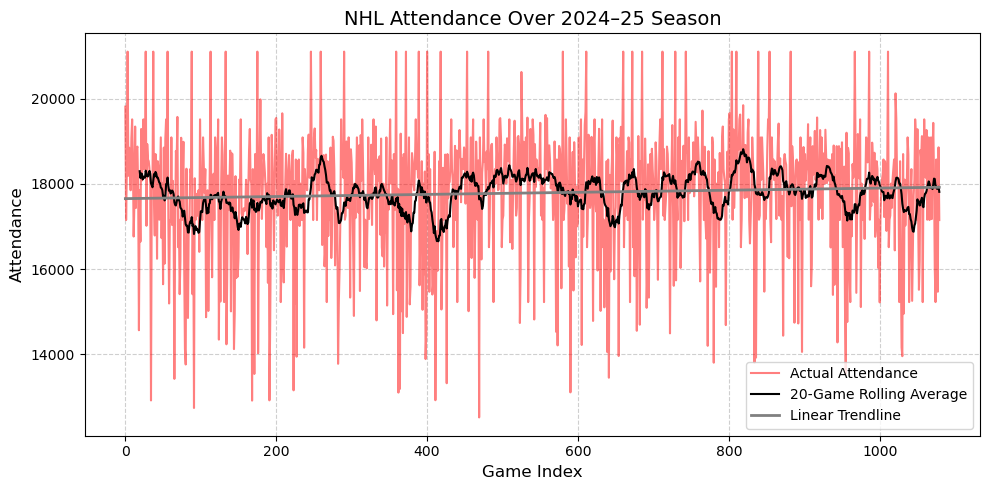

In [3]:
# Calculate rolling average (e.g., window of 10 games)
df_att_25['RollingAvg'] = df_att_25['A'].rolling(window=20).mean()

# Create x values (Game Index)
x = np.arange(len(df_att_25))
y = df_att_25['A']

# Fit a linear trendline (1st degree polynomial)
coef = np.polyfit(x, y, deg=1)
trendline = np.poly1d(coef)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df_att_25['A'], color='red', alpha=0.5, label='Actual Attendance')
plt.plot(df_att_25['RollingAvg'], color='black', label='20-Game Rolling Average')
plt.plot(x, trendline(x), color='gray', linestyle='-', linewidth=2, label='Linear Trendline')

plt.title('NHL Attendance Over 2024–25 Season', fontsize=14)
plt.xlabel('Game Index', fontsize=12)
plt.ylabel('Attendance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

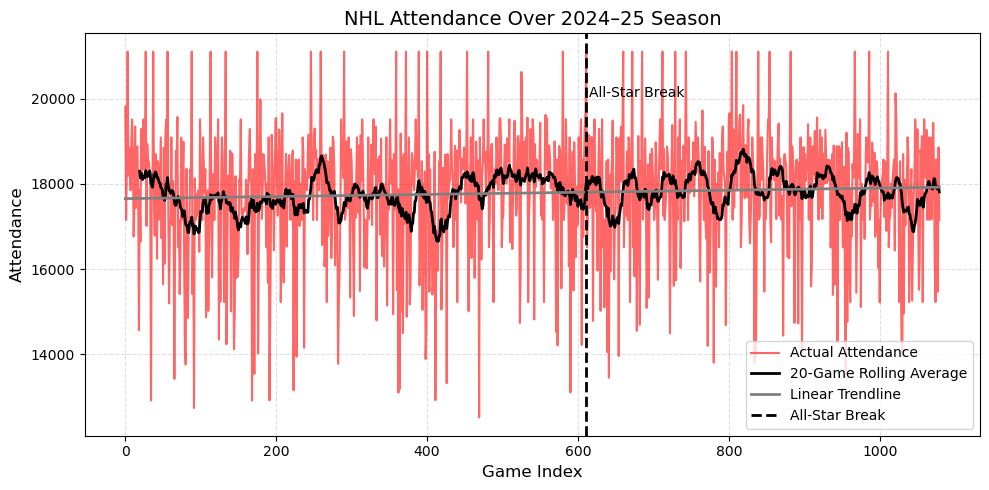

In [4]:
# Calculate rolling average (e.g., window of 10 games)
df_att_25['RollingAvg'] = df_att_25['A'].rolling(window=20).mean()

# Create x values (Game Index)
x = np.arange(len(df_att_25))
y = df_att_25['A']

# Fit a linear trendline (1st degree polynomial)
coef = np.polyfit(x, y, deg=1)
trendline = np.poly1d(coef)

# Colors aligned with your theme
actual_color = 'red'
rolling_avg_color = 'black'
trendline_color = 'gray'
all_star_color = 'black'

plt.figure(figsize=(10, 5))
plt.plot(df_att_25['A'], color=actual_color, alpha=0.6, label='Actual Attendance')
plt.plot(df_att_25['RollingAvg'], color=rolling_avg_color, linewidth=2, label='20-Game Rolling Average')
plt.plot(x, trendline(x), color=trendline_color, linestyle='-', linewidth=2, label='Linear Trendline')

# Mark the All-Star Break
plt.axvline(x=all_star_index, color=all_star_color, linestyle='--', linewidth=2, label='All-Star Break')
plt.text(all_star_index + 5, df_att_25['A'].max() * 0.95, 'All-Star Break', 
         color=all_star_color, fontsize=10)

# Aesthetics
plt.title('NHL Attendance Over 2024–25 Season', fontsize=14)
plt.xlabel('Game Index', fontsize=12)
plt.ylabel('Attendance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Filter and display games with PA <= 0.75
low_pa_games = df_att_25[df_att_25['PA'] <= 0.75]
low_pa_games[['H', 'V', 'PA', 'A', 'MDAY', 'TDAY', 'WDAY', 'ThDAY', 'FDAY', 'SDAY', 'SuDAY']]

,H,V,PA,A,MDAY,TDAY,WDAY,ThDAY,FDAY,SDAY,SuDAY
83,Columbus Blue Jackets,Toronto Maple Leafs,0.722514,14852.0,0,1,0,0,0,0,0
91,New York Islanders,Detroit Red Wings,0.744405,12739.0,0,1,0,0,0,0,0
126,Columbus Blue Jackets,Edmonton Oilers,0.741243,15237.0,1,0,0,0,0,0,0
144,Philadelphia Flyers,St. Louis Blues,0.722834,14122.0,0,0,0,1,0,0,0
227,Buffalo Sabres,St. Louis Blues,0.732724,13943.0,0,0,0,1,0,0,0
469,San Jose Sharks,Colorado Avalanche,0.717924,12517.0,0,0,0,1,0,0,0
630,Columbus Blue Jackets,Philadelphia Flyers,0.730590,15018.0,0,1,0,0,0,0,0
641,Buffalo Sabres,Carolina Hurricanes,0.706763,13449.0,0,0,1,0,0,0,0
772,Buffalo Sabres,Columbus Blue Jackets,0.746124,14198.0,0,1,0,0,0,0,0
836,Buffalo Sabres,Anaheim Ducks,0.731568,13921.0,0,1,0,0,0,0,0
